## IMPORTACION DE LIBRERIAS

In [34]:
# Prcesamiento
import pandas as pd
import datetime
import numpy as np

# machine learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# graficos
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## Lectura procesamiento y escalado de datos para la segementacion

In [35]:
bucket_name = "datospco"
datos = pd.read_csv(f"s3://{bucket_name}/{'datos_train.csv'}")

In [36]:
datos.columns

Index(['id_cliente', 'fecha', 'id_aliado', 'tipo_transaccion',
       'id_transaccion', 'puntos', 'valor_transaccion', 'categoria', 'genero',
       'fecha_nacimiento', 'estrato_social', 'estado_civil', 'ocupacion',
       'ciudad', 'saldo_puntos'],
      dtype='object')

In [37]:
datos.drop(
    columns=[
        "id_aliado",
        "id_transaccion",
        "puntos",
        "genero",
        "fecha_nacimiento",
        "ciudad",
    ],
    inplace=True,
)

In [38]:
datos["fecha"] = pd.to_datetime(datos["fecha"])
datos["estrato_social"] = datos["estrato_social"].astype(str)

In [39]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20173 entries, 0 to 20172
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id_cliente         20173 non-null  int64         
 1   fecha              20173 non-null  datetime64[ns]
 2   tipo_transaccion   20173 non-null  object        
 3   valor_transaccion  20173 non-null  float64       
 4   categoria          20173 non-null  object        
 5   estrato_social     20173 non-null  object        
 6   estado_civil       20173 non-null  object        
 7   ocupacion          20173 non-null  object        
 8   saldo_puntos       20173 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(5)
memory usage: 1.4+ MB


In [40]:
fecha_max = datos["fecha"].max()

### Variables categoricas

In [41]:
# dummies = pd.get_dummies(
#     datos[["id_cliente", "categoria", "estrato_social", "estado_civil", "ocupacion"]],
#     columns=["categoria", "estrato_social", "estado_civil", "ocupacion"],
#     drop_first=True,
# )

# dummies_group = dummies.groupby("id_cliente").mean()

### Variable de redencion y ventas

In [42]:
df_valor = (
    datos.groupby(by=["id_cliente", "tipo_transaccion"])
    .agg(valor=("valor_transaccion", "sum"))
    .reset_index()
    .pivot(index="id_cliente", columns="tipo_transaccion", values="valor")
)

df_valor.columns = ["valorRedemption", "valorSale"]

df_valor = df_valor.fillna(0)

In [43]:
df_valor

,valorRedemption,valorSale
id_cliente,,
814950,0.0,673005.0
8423150,0.0,397981.0
14332200,160418.0,11082333.0
14770250,0.0,179920.0
14858350,244050.0,15649282.0
...,...,...
1158007749,0.0,2968842.0
1172503275,0.0,8461282.0
1185008353,0.0,711852.0


### Variables rfm

In [44]:
# Calcular las variables RFM
rfm_df = (
    datos.groupby(by=["id_cliente"])
    .agg(
        recencia=("fecha", lambda x: (fecha_max - x.max()).days),
        frecuencia=("fecha", "count"),
    )
    .reset_index()
)

In [45]:
rfm_df

,id_cliente,recencia,frecuencia
0,814950,83,56
1,8423150,70,30
2,14332200,61,349
3,14770250,246,3
4,14858350,30,56
...,...,...,...
215,1158007749,270,25
216,1172503275,5,34
217,1185008353,58,44
218,1192004213,57,4


## Union de los datos

In [46]:
df_final = df_valor.merge(rfm_df, how="left", on="id_cliente")

# df_final = df_final.merge(dummies_group, how="left",on="id_cliente")

In [47]:
df_final

,id_cliente,valorRedemption,valorSale,recencia,frecuencia
0,814950,0.0,673005.0,83,56
1,8423150,0.0,397981.0,70,30
2,14332200,160418.0,11082333.0,61,349
3,14770250,0.0,179920.0,246,3
4,14858350,244050.0,15649282.0,30,56
...,...,...,...,...,...
215,1158007749,0.0,2968842.0,270,25
216,1172503275,0.0,8461282.0,5,34
217,1185008353,0.0,711852.0,58,44
218,1192004213,0.0,906745.0,57,4


## Segementacion

In [48]:
X = df_final.drop(columns="id_cliente")

In [49]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

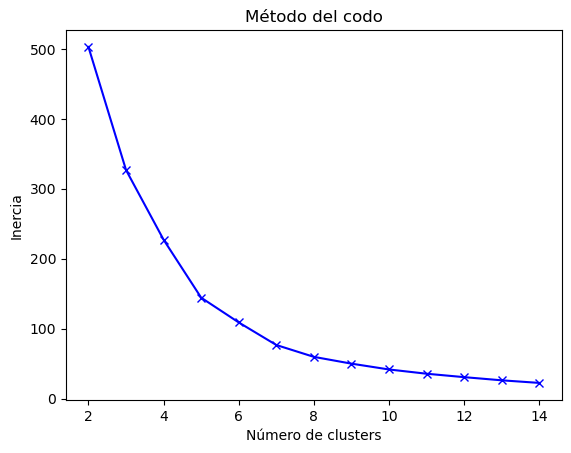

In [50]:
inercia = []
K = range(2, 15)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

plt.plot(K, inercia, "bx-")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

In [51]:
k_optimo = 7
kmeans = KMeans(n_clusters=k_optimo, random_state=42)
df_final["cluster"] = kmeans.fit_predict(X_scaled)

In [52]:
df_clusters = df_final.drop(columns="id_cliente").groupby("cluster").mean()

In [53]:
clust_count = df_final["cluster"].value_counts()

In [54]:
clust_count = clust_count.reset_index()

In [55]:
clust_count.merge(df_clusters, how="left", on=["cluster"]).round(2).set_index("cluster")

,count,valorRedemption,valorSale,recencia,frecuencia
cluster,,,,,
0,111,19503.42,4.712708e+06,66.23,57.99
2,58,862.72,6.484778e+05,286.22,14.98
6,32,0.00,1.201652e+05,556.12,4.06
3,15,206675.60,2.206960e+07,45.20,603.33
1,2,1498543.00,1.502434e+08,1.50,713.00
4,1,3249112.00,1.953477e+08,8.00,1951.00
5,1,0.00,2.667379e+08,1.00,310.00


## DBSCAN

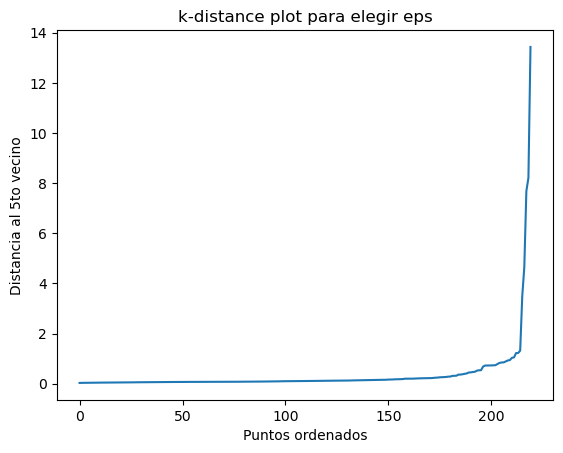

In [56]:
neighbors = NearestNeighbors(n_neighbors=5)  # n_neighbors = min_samples
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:,4])  # distancia al 5to vecino
plt.plot(distances)
plt.ylabel('Distancia al 5to vecino')
plt.xlabel('Puntos ordenados')
plt.title('k-distance plot para elegir eps')
plt.show()

In [57]:
dbscan = DBSCAN(eps=1.7, min_samples=5)  # ajusta eps según tus datos
clusters = dbscan.fit_predict(X_scaled)
df_final['cluster2'] = clusters

In [58]:
df_clusters = df_final.drop(columns="id_cliente").groupby("cluster2").mean()
clust_count = df_final["cluster2"].value_counts()
clust_count = clust_count.reset_index()

In [59]:
clust_count.merge(df_clusters, how="left", on=["cluster2"]).round(2).set_index("cluster2")

,count,valorRedemption,valorSale,recencia,frecuencia,cluster
cluster2,,,,,,
0,215,23117.93,3.991461e+06,197.01,70.06,1.63
-1,5,1318179.00,1.600040e+08,16.20,1022.20,2.80
